In [1]:
import json
from pathlib import Path

In [2]:
SONICS_BASE_PATH = Path("/mnt/data/kusnierz/audio-data/Sonics")
DATA = SONICS_BASE_PATH / "all_data"
METADATA = DATA / "metadata.json"

In [4]:
import pandas as pd
import json
from collections import Counter

# Paths to CSVs (assuming they are in SONICS_BASE_PATH)
fake_csv = SONICS_BASE_PATH / "fake_songs.csv"
real_csv = SONICS_BASE_PATH / "real_songs.csv"

# Load CSVs
df_fake = pd.read_csv(fake_csv).fillna("")
df_real = pd.read_csv(real_csv).fillna("")

# Expected counts
expected_fake = df_fake.groupby('split').size().to_dict()  # deepfake per split
expected_real = df_real.groupby('split').size().to_dict()  # bonafide per split

print("Expected deepfake (fake_songs.csv):")
for split, count in expected_fake.items():
    print(f"  {split}: {count}")
print(f"Total deepfake: {sum(expected_fake.values())}")

print("\nExpected bonafide (real_songs.csv):")
for split, count in expected_real.items():
    print(f"  {split}: {count}")
print(f"Total bonafide: {sum(expected_real.values())}")

# Load metadata
with open(METADATA, 'r') as f:
    metadata = json.load(f)

# Actual counts from metadata
actual_counts = {}
for entry in metadata:
    split = entry.get('set', 'unknown')
    spoof = entry.get('spoof', 'unknown')
    if split not in actual_counts:
        actual_counts[split] = Counter()
    actual_counts[split][spoof] += 1

print("\nActual downloaded (metadata.json):")
total_actual = 0
for split, counts in actual_counts.items():
    print(f"  {split}: {dict(counts)}")
    total_actual += sum(counts.values())
print(f"Total downloaded: {total_actual}")

# Comparison
print("\nComparison per split:")
all_splits = set(expected_fake.keys()) | set(expected_real.keys()) | set(actual_counts.keys())
for split in sorted(all_splits):
    exp_deep = expected_fake.get(split, 0)
    exp_bona = expected_real.get(split, 0)
    act = actual_counts.get(split, Counter())
    act_deep = act.get('deepfake', 0)
    act_bona = act.get('bonafide', 0)
    print(f"  {split}: Expected deepfake {exp_deep}, bonafide {exp_bona}; Actual deepfake {act_deep}, bonafide {act_bona}")

/tmp/ipykernel_1567722/2818231204.py:10: DtypeWarning: Columns (9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_fake = pd.read_csv(fake_csv).fillna("")


Expected deepfake (fake_songs.csv):
  test: 12778
  train: 34023
  valid: 2273
Total deepfake: 49074

Expected bonafide (real_songs.csv):
  test: 13237
  train: 32686
  valid: 2167
Total bonafide: 48090

Actual downloaded (metadata.json):
  train: {'deepfake': 34023, 'bonafide': 30032}
  test: {'deepfake': 12778, 'bonafide': 12127}
  valid: {'deepfake': 2273, 'bonafide': 1988}
Total downloaded: 93221

Comparison per split:
  test: Expected deepfake 12778, bonafide 13237; Actual deepfake 12778, bonafide 12127
  train: Expected deepfake 34023, bonafide 32686; Actual deepfake 34023, bonafide 30032
  valid: Expected deepfake 2273, bonafide 2167; Actual deepfake 2273, bonafide 1988


Total entries: 93221

Spoof types:
spoof
deepfake    49074
bonafide    44147
Name: count, dtype: int64

Sets:
set
train    64055
test     24905
valid     4261
Name: count, dtype: int64

Labels:
label
mostly fake    40769
half fake       6132
full fake       2173
Name: count, dtype: int64

Algorithms:
algorithm
chirp-v3.5            19057
udio-120s             18745
udio-30s               4903
chirp-v3               4285
chirp-v2-xxl-alpha     2084
Name: count, dtype: int64

Moods (top 10):
mood
                46901
disenchanted       44
whimsical          42
amused             42
confident          42
optimistic         41
powerless          41
energetic          40
hateful            39
regretful          37
Name: count, dtype: int64

Topics (top 10):
topic
                                       46901
overcoming adversity                      15
stone age (history)                       15
convolution vs transformer (AI)           15
notre dame cathedral (architecture)       14
alber

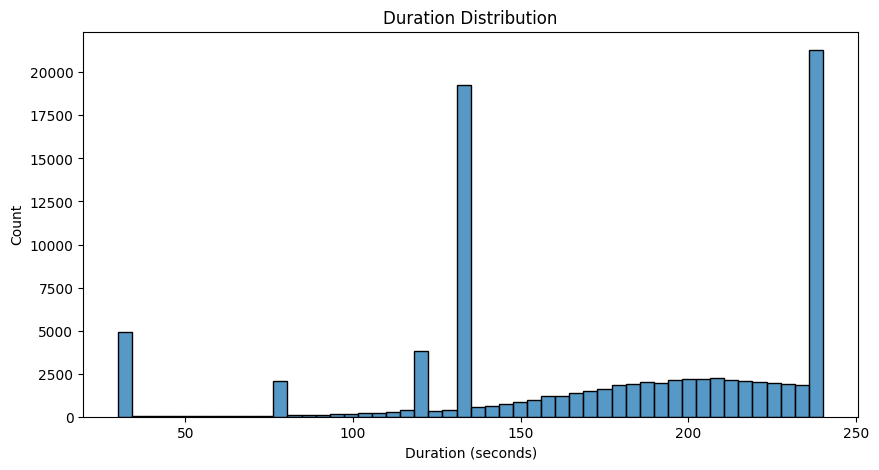

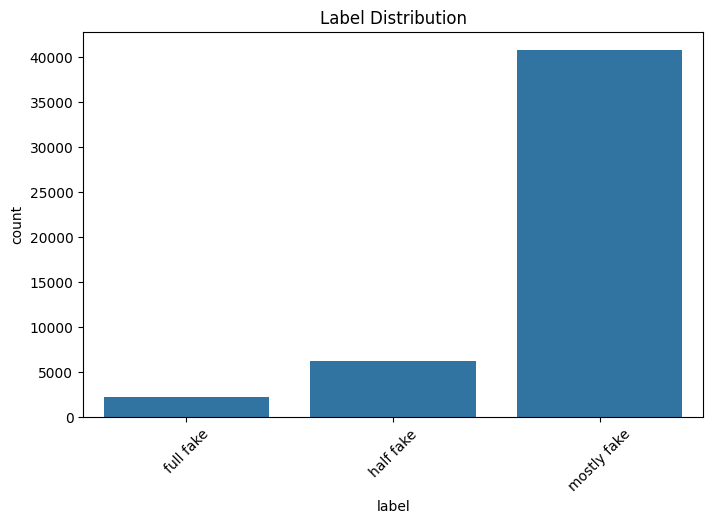

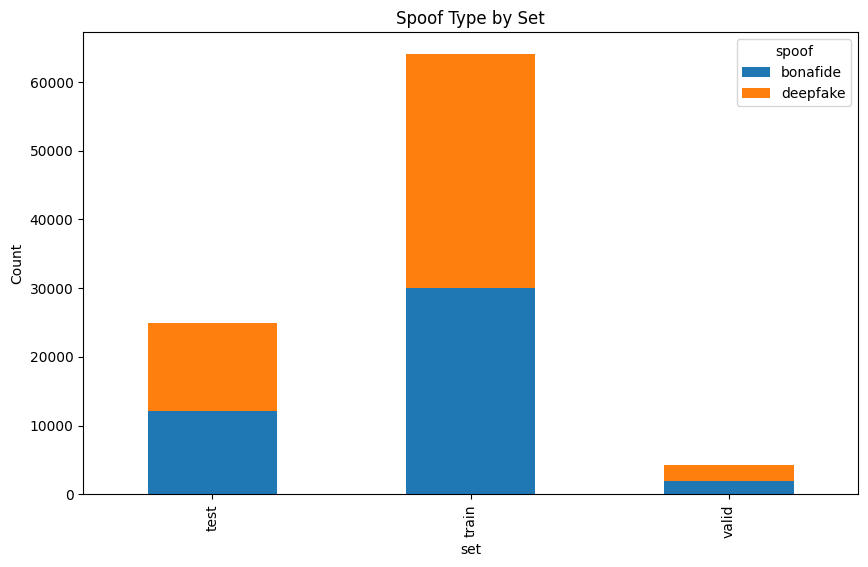

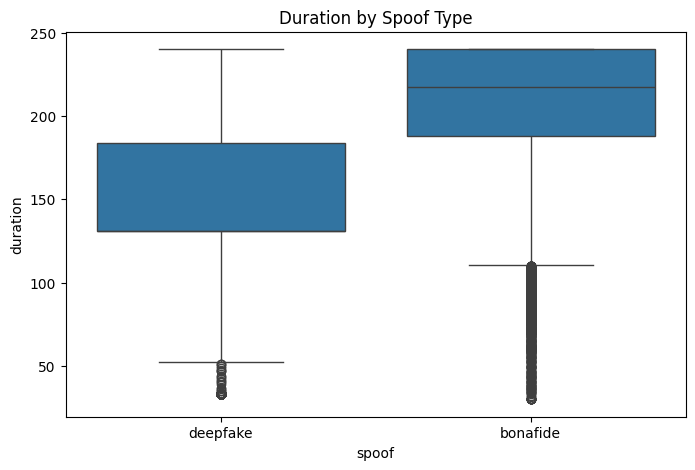

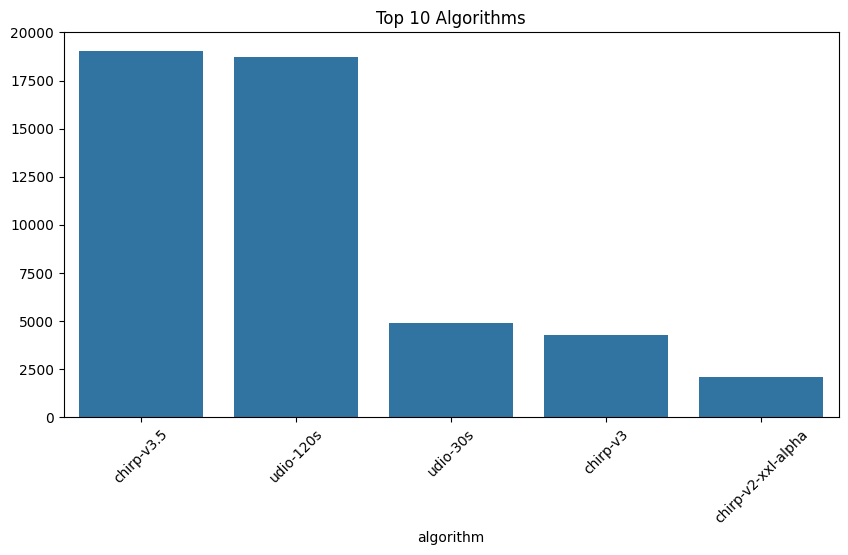

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load metadata into DataFrame
df_meta = pd.DataFrame(metadata)

# Convert duration to float
df_meta['duration'] = pd.to_numeric(df_meta['duration'], errors='coerce')

# Basic stats
print("Total entries:", len(df_meta))
print("\nSpoof types:")
print(df_meta['spoof'].value_counts())

print("\nSets:")
print(df_meta['set'].value_counts())

print("\nLabels:")
print(df_meta['label'].value_counts())

print("\nAlgorithms:")
print(df_meta['algorithm'].value_counts())

print("\nMoods (top 10):")
print(df_meta['mood'].value_counts().head(10))

print("\nTopics (top 10):")
print(df_meta['topic'].value_counts().head(10))

# Duration analysis
print("\nDuration stats:")
print(df_meta['duration'].describe())

# Plot duration histogram
plt.figure(figsize=(10,5))
sns.histplot(df_meta['duration'].dropna(), bins=50)
plt.title('Duration Distribution')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.show()

# Label distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df_meta, x='label')
plt.title('Label Distribution')
plt.xticks(rotation=45)
plt.show()

# Spoof by set
spoof_by_set = df_meta.groupby(['set', 'spoof']).size().unstack(fill_value=0)
spoof_by_set.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Spoof Type by Set')
plt.ylabel('Count')
plt.show()

# Duration by spoof
plt.figure(figsize=(8,5))
sns.boxplot(data=df_meta, x='spoof', y='duration')
plt.title('Duration by Spoof Type')
plt.show()

# Top algorithms
top_alg = df_meta['algorithm'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_alg.index, y=top_alg.values)
plt.title('Top 10 Algorithms')
plt.xticks(rotation=45)
plt.show()

### Train, Val, Test

In [5]:
import polars

In [3]:
train = SONICS_BASE_PATH / "train.csv"
test = SONICS_BASE_PATH / "test.csv"
valid = SONICS_BASE_PATH / "valid.csv"

In [6]:
df = polars.read_csv(train)

In [14]:
df.filter(df['artist_overlap'].is_not_null())

id,lyrics,algorithm,style,filename,bit_rate,duration,source,lyrics_feature,topic,genre,mood,label,filepath,target,skip_time,no_vocal,split,title,artist,year,youtube_id,artist_overlap
i64,str,str,str,str,f64,f64,str,str,str,str,str,str,str,i64,f64,bool,str,str,str,str,str,str
693,"""[Intro] [Verse 1] Now here yo…",null,null,"""real_00693""",41017.0,240.084,"""youtube""",null,null,null,null,"""real""","""real_songs/real_00693.mp3""",0,21.327219,false,"""train""","""Dreams""","""Fleetwood Mac""","""1977.0""","""5oWyMakvQew""","""False"""
1164,"""[Intro] (spoken) ""Alright guys…",null,null,"""real_01164""",37845.0,231.372,"""youtube""",null,null,null,null,"""real""","""real_songs/real_01164.mp3""",0,15.522219,false,"""train""","""Mine Diamonds""","""MineCraft Awesome Parodys""","""2016.0""","""dgha9S39Y6M""","""True"""
1318,"""[Intro] Fuck [Verse 1] Listen…",null,null,"""real_01318""",38548.0,240.084,"""youtube""",null,null,null,null,"""real""","""real_songs/real_01318.mp3""",0,86.498469,false,"""train""","""The Chain""","""Fleetwood Mac""","""1977.0""","""iLC-tHvkNvI""","""False"""
1409,"""[Intro] Gun 'em down (Gun 'em …",null,null,"""real_01409""",40107.0,193.428,"""youtube""",null,null,null,null,"""real""","""real_songs/real_01409.mp3""",0,0.891594,false,"""train""","""Armed and Dangerous""","""Juice WRLD""","""2018.0""","""cr82wSBZeeQ""","""True"""
1683,"""[Intro: Barbie & Ken] Hiya, Ba…",null,null,"""real_01683""",38869.0,201.168,"""youtube""",null,null,null,null,"""real""","""real_songs/real_01683.mp3""",0,9.025344,false,"""train""","""Barbie Girl""","""Aqua""","""1997.0""","""J-ii-82fsw8""","""False"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
52530,"""[Verse 1] Shut up lotus auto E…",null,null,"""real_52530""",34070.0,167.472,"""youtube""",null,null,null,null,"""real""","""real_songs/real_52530.mp3""",0,60.224094,false,"""train""","""Fuck Puppet""","""Machine Girl""","""2018.0""","""9m5o4vJdXP0""","""True"""
52716,"""[Verse 1] All the girls all da…",null,null,"""real_52716""",35480.0,197.604,"""youtube""",null,null,null,null,"""real""","""real_songs/real_52716.mp3""",0,11.809719,false,"""train""","""Red Clay Halo""","""Gillian Welch""","""2001.0""","""b2Ib4eIbAqE""","""False"""
52952,"""[Verse 1] One bad night I’ll h…",null,null,"""real_52952""",36636.0,194.868,"""youtube""",null,null,null,null,"""real""","""real_songs/real_52952.mp3""",0,5.160969,false,"""train""","""Every Night My Teeth Are Falli…","""The Antlers""","""2011.0""","""g3KAstxRIZk""","""False"""


In [6]:
embedds_path = Path("/mnt/data/kusnierz/audio-data/Sonics/preprocessed")
mert = embedds_path / "mert"
w2v = embedds_path / "wav2vec"

In [8]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: /usr/bin/python3 -m pip install --upgrade pip


In [3]:
import numpy as np
import torch
import sys
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tqdm.notebook import tqdm
import random

print(f"Current torch version: {torch.__version__} (Not used for loading .npy files)")
print(f"Current numpy version: {np.__version__}")

Current torch version: 2.9.1+cu128 (Not used for loading .npy files)
Current numpy version: 2.3.5


In [4]:
def load_and_visualize(file_list, model_name="Model", limit=2000):
    features = []
    labels = []
    
    print(f"Loading {model_name} data (max {limit} samples)...")
    
    # Shuffle list inside to get random distribution if limiting
    files_to_process = list(file_list)
    random.seed(42)
    random.shuffle(files_to_process)
    files_to_process = files_to_process[:limit]
    
    for p in tqdm(files_to_process, desc=f"Loading {model_name}"):
        # Determine label
        if "bonafide" in p.name:
            label = 0 # encoded as 0
        elif "deepfake" in p.name or "spoof" in p.name:
            label = 1 # encoded as 1
        else:
            continue
            
        try:
            # Load numpy array directly
            t = np.load(str(p))
            
            # Average Pooling over time to get single vector [Dim]
            if t.ndim == 2:
                # Global Mean Pooling
                # t shape: [seq_len, hidden_dim]
                emb = np.mean(t, axis=0)
                features.append(emb)
                labels.append(label) # <--- FIXED: Appending labels matched with features
        except Exception as e:
            # print(f"Failed {p.name}: {e}")
            pass
            
    X = np.array(features)
    y = np.array(labels, dtype=int)
    
    if len(X) == 0:
        print("No data found. Did you re-run the preprocessing script?")
        return

    print(f"--- Data Diagnostics for {model_name} ---")
    print(f"Data shape: {X.shape}")
    print(f"Labels shape: {y.shape}")
    if len(y) > 0:
        print(f"Class distribution: {np.bincount(y)} (0=Bonafide, 1=Deepfake)")
    else:
        print("Class distribution: EMPTY! (Check label parsing)")
        
    print(f"Contains NaNs: {np.isnan(X).any()}")
    print(f"Min value: {np.min(X):.4f}")
    print(f"Max value: {np.max(X):.4f}")
    print(f"Mean value: {np.mean(X):.4f}")
    
    # Clean NaNs if present (Simple imputation)
    if np.isnan(X).any():
        print("WARNING: NaNs detected. Replacing with 0 for visualization.")
        X = np.nan_to_num(X)

    if len(X) < 10: # Lowered limit for test runs with small data
        print(f"Not enough data to plot (found {len(X)}, need at least 10).")
        return

    # --- PLOTTING ---
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Check if we have both classes for better plotting, or just one
    unique_classes = np.unique(y)
    if len(unique_classes) < 2:
        print(f"WARNING: Only one class detected in data: {unique_classes}. t-SNE might look weird.")

    # 1. PCA
    try:
        n_comp = min(2, len(X), len(X[0]))
        pca = PCA(n_components=n_comp)
        X_pca = pca.fit_transform(X)
        
        scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.7, s=15)
        axes[0].set_title(f"{model_name} - PCA")
        axes[0].set_xlabel("PC1")
        axes[0].set_ylabel("PC2")
        axes[0].grid(True, alpha=0.3)
    except Exception as e:
        print(f"PCA Error: {e}")
    
    # 2. t-SNE
    try:
        # Perplexit must be less than number of samples
        perplex = min(30, len(X) - 1)
        tsne = TSNE(n_components=2, init='pca', learning_rate='auto', random_state=42, perplexity=perplex)
        X_tsne = tsne.fit_transform(X)
        
        scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='coolwarm', alpha=0.7, s=15)
        axes[1].set_title(f"{model_name} - t-SNE")
        axes[1].grid(True, alpha=0.3)
    except Exception as e:
        print(f"t-SNE Error: {e}")
    
    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.coolwarm(0.0), label='Bonafide'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.coolwarm(1.0), label='Deepfake')
    ]
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2)
    
    plt.tight_layout()
    plt.show()

Found 52 MERT files
Found 52 Wav2Vec files

--- Checking dimensions (first 5 samples) ---
File: test_Celtic_Frost_Progeny_bonafide.npy
  Class: bonafide
  MERT shape:    (5996, 1024)
  Wav2Vec shape: (5996, 1024)
------------------------------
File: test_Coolio_The_Winner_bonafide.npy
  Class: bonafide
  MERT shape:    (5996, 1024)
  Wav2Vec shape: (5996, 1024)
------------------------------
File: test_Lil_Xtra_Make_It_Through_Fall_bonafide.npy
  Class: bonafide
  MERT shape:    (5996, 1024)
  Wav2Vec shape: (5996, 1024)
------------------------------
File: test_Revocation_Of_Unworldly_Origin_bonafide.npy
  Class: bonafide
  MERT shape:    (5996, 1024)
  Wav2Vec shape: (5996, 1024)
------------------------------
File: test_Saint_Raymond_Movie_in_My_Mind_bonafide.npy
  Class: bonafide
  MERT shape:    (5996, 1024)
  Wav2Vec shape: (5996, 1024)
------------------------------

--- Generating Plots ---
Loading MERT data (max 2000 samples)...


Loading MERT:   0%|          | 0/52 [00:00<?, ?it/s]

--- Data Diagnostics for MERT ---
Data shape: (52, 1024)
Labels shape: (52,)
Class distribution: [27 25] (0=Bonafide, 1=Deepfake)
Contains NaNs: False
Min value: -1.9033
Max value: 4.8503
Mean value: 0.0069


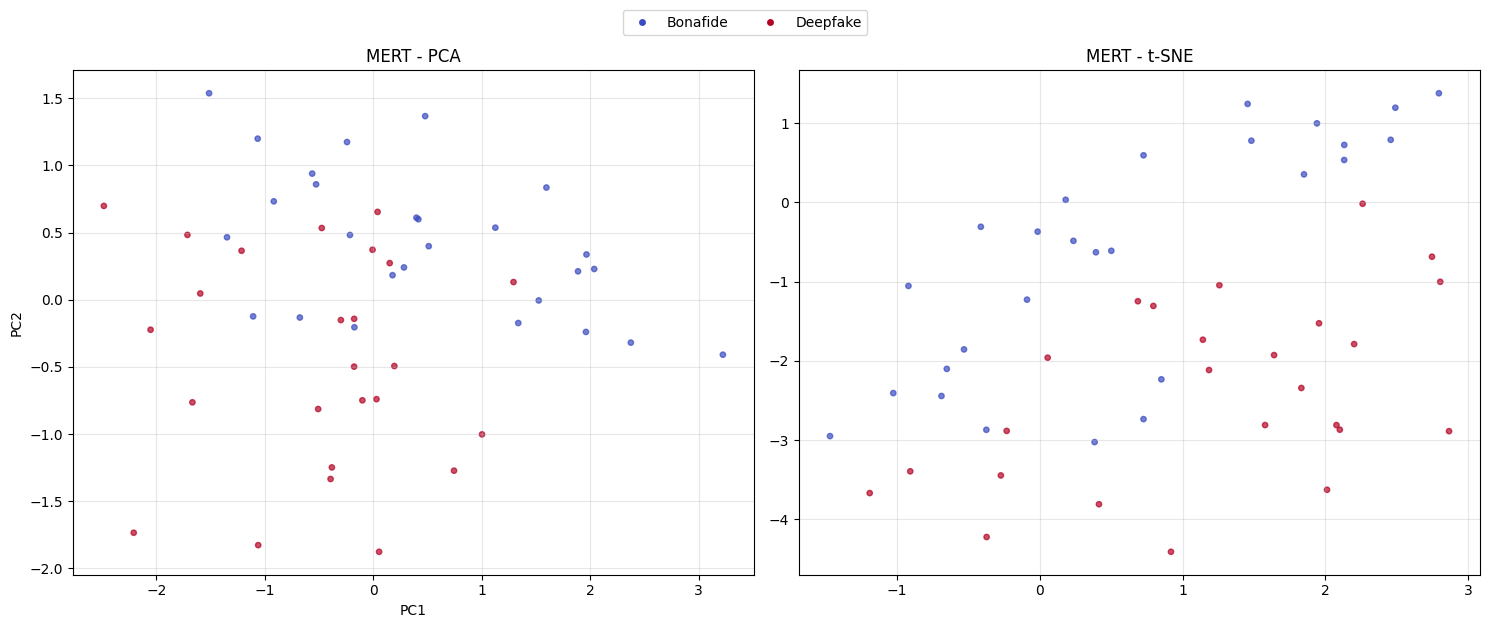

Loading Wav2Vec data (max 2000 samples)...


Loading Wav2Vec:   0%|          | 0/52 [00:00<?, ?it/s]

--- Data Diagnostics for Wav2Vec ---
Data shape: (52, 1024)
Labels shape: (52,)
Class distribution: [27 25] (0=Bonafide, 1=Deepfake)
Contains NaNs: False
Min value: -1.2076
Max value: 1.0817
Mean value: 0.0005


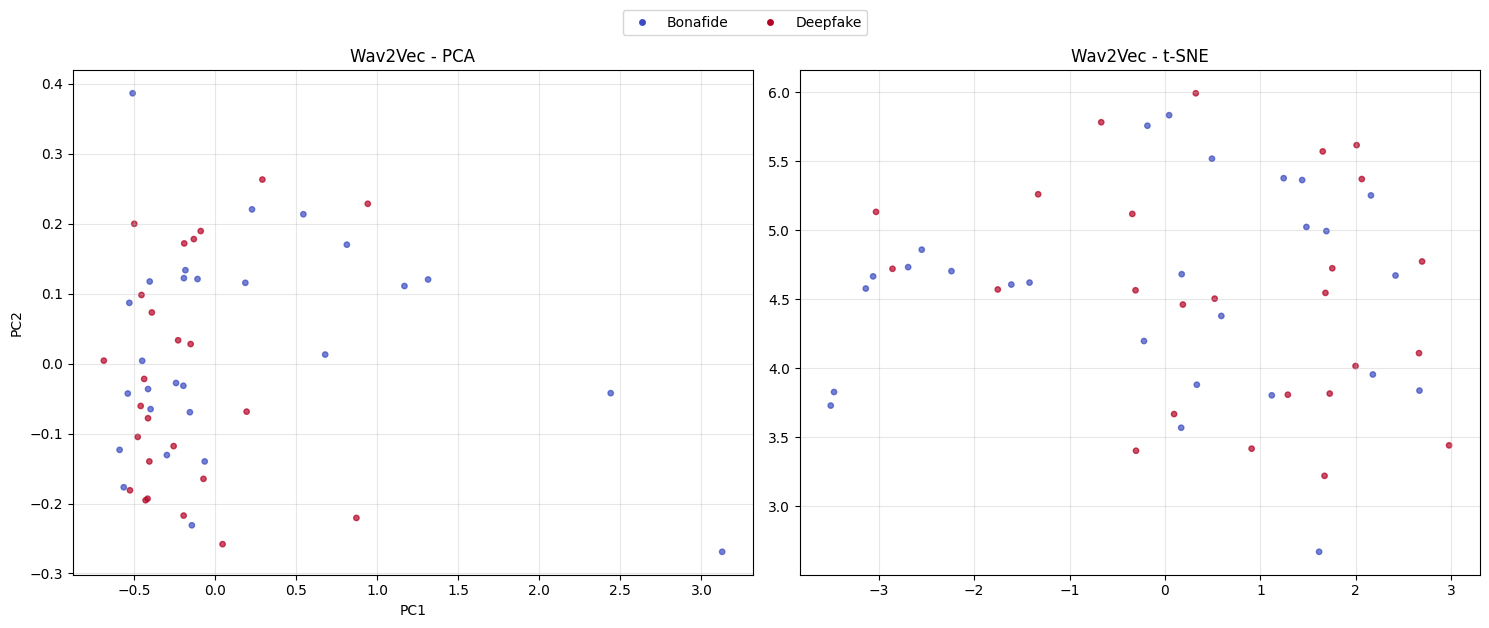

In [7]:
# 1. Get list of files
mert_files = sorted(list(mert.glob("*.npy")))
# Assuming wav2vec files have same names
w2v_files = sorted(list(w2v.glob("*.npy")))

print(f"Found {len(mert_files)} MERT files")
print(f"Found {len(w2v_files)} Wav2Vec files")

# 2. COMPARISON OF DIMENSIONS
print("\n--- Checking dimensions (first 5 samples) ---")
for i in range(min(5, len(mert_files))):
    m_path = mert_files[i]
    w_path = w2v / m_path.name
    
    if not w_path.exists():
        print(f"WARNING: Missing W2V file for {m_path.name}")
        continue
    
    try:
        # Infer class from name
        cls = "bonafide" if "bonafide" in m_path.name else "deepfake" if "deepfake" in m_path.name else "unknown"
        
        m_arr = np.load(str(m_path))
        w_arr = np.load(str(w_path))
        
        print(f"File: {m_path.name}")
        print(f"  Class: {cls}")
        print(f"  MERT shape:    {m_arr.shape}")
        print(f"  Wav2Vec shape: {w_arr.shape}")
        print("-" * 30)
    except Exception as e:
        print(f"Error loading {m_path.name}: {e}")

# 3. VISUALIZATION
print("\n--- Generating Plots ---")
load_and_visualize(mert_files, model_name="MERT")
load_and_visualize(w2v_files, model_name="Wav2Vec")

In [8]:
# Analiza "Too Good To Be True"
import numpy as np
from tqdm.notebook import tqdm

def check_feature_leakage(file_list, model_name="Model", limit=200):
    bf_feats = []
    df_feats = []
    
    files_to_process = list(file_list)[:limit] # biorę pierwsze 'limit' plików
    
    for p in tqdm(files_to_process, desc=f"Analyzing {model_name}"):
        try:
            arr = np.load(str(p))
            # Średnia po czasie [Dim]
            mean_vec = np.mean(arr, axis=0)
            
            if "bonafide" in p.name:
                bf_feats.append(mean_vec)
            elif "deepfake" in p.name or "spoof" in p.name:
                df_feats.append(mean_vec)
        except Exception:
            pass

    bf = np.array(bf_feats)
    df = np.array(df_feats)
    
    if len(bf) == 0 or len(df) == 0:
        print(f"Skipping {model_name}: Not enough samples per class.")
        return

    # Policz średnią globalną dla klas
    mean_bf = np.mean(bf, axis=0)
    mean_df = np.mean(df, axis=0)
    
    # Różnica absolutna per cecha
    diff = np.abs(mean_bf - mean_df)
    
    max_diff_idx = np.argmax(diff)
    max_diff_val = diff[max_diff_idx]
    
    print(f"--- {model_name} Leakage Check ---")
    print(f"Max różnica średnich na cesze {max_diff_idx}: {max_diff_val:.4f}")
    
    # Sprawdź separowalność na tej jednej cesze
    bf_vals = bf[:, max_diff_idx]
    df_vals = df[:, max_diff_idx]
    
    print(f"Bonafide range: {bf_vals.min():.4f} to {bf_vals.max():.4f}")
    print(f"Deepfake range: {df_vals.min():.4f} to {df_vals.max():.4f}")
    
    if bf_vals.max() < df_vals.min() or df_vals.max() < bf_vals.min():
        print("!!! ALARM !!! Pełna separacja na JEDNYM wymiarze!")
    else:
        print("Brak trywialnej separacji na najlepszej cesze.")

# Uruchom dla MERT i W2V
print("Sprawdzam W2V...")
check_feature_leakage(w2v_files, model_name="Wav2Vec")
print("\nSprawdzam MERT...")
check_feature_leakage(mert_files, model_name="MERT")

Sprawdzam W2V...


Analyzing Wav2Vec:   0%|          | 0/52 [00:00<?, ?it/s]

--- Wav2Vec Leakage Check ---
Max różnica średnich na cesze 371: 0.0705
Bonafide range: -1.1910 to -0.3765
Deepfake range: -1.2076 to -0.7985
Brak trywialnej separacji na najlepszej cesze.

Sprawdzam MERT...


Analyzing MERT:   0%|          | 0/52 [00:00<?, ?it/s]

--- MERT Leakage Check ---
Max różnica średnich na cesze 229: 0.9110
Bonafide range: -0.0373 to 1.8552
Deepfake range: -1.9033 to 1.3268
Brak trywialnej separacji na najlepszej cesze.
